In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
path=""
data_radios=pd.read_csv(path+'reponses_radio_test1.csv',sep=';')
#test0 est là pour retrouver les résultats de l'énoncé papier, test1 les résultats des 4 premières fonctions et des deux premiers graphiques et test2 les deux derniers graphiques

In [17]:
def calcul_eff_obs(mon_df,var_lignes,var_colonnes):
    # renverse le dataframe
    res = mon_df.groupby([var_lignes,var_colonnes]).size().unstack()
    return res

In [18]:
res_list_jazz=[16, 9, 13, 2, 19, 4]
res_list_radio6=[8, 52, 2, 4, 1, 75, 29, 29]
eff_obs_radios=calcul_eff_obs(data_radios,'Style musical','Radio')
print('test calcul_eff_obs : ',len(res_list_jazz)-list(np.isclose(eff_obs_radios.loc['Jazz'],res_list_jazz)).count(True)==0)
print('test calcul_eff_obs : ',len(res_list_radio6)-list(np.isclose(eff_obs_radios['Radio 6'],res_list_radio6)).count(True)==0)

test calcul_eff_obs :  True
test calcul_eff_obs :  True


In [19]:
def calcul_eff_theo(eff_obs):
    total_ligne = eff_obs.sum(axis=1)
    total_colone = eff_obs.sum(axis=0)
    total_element = eff_obs.values.sum()
    tab = np.outer(total_ligne,(total_colone/total_element))
    res = pd.DataFrame(tab,eff_obs.index,eff_obs.columns)
    return res

    

In [20]:
res_list_indie=[4.41, 6.384, 9.576, 5.754, 7.476, 8.4]
res_list_radio2=[17.784, 27.056, 6.384, 9.576, 8.816, 31.464, 23.56, 27.36]
eff_theo_radios=calcul_eff_theo(eff_obs_radios)
print('test calcul_eff_theo : ',len(res_list_indie)-list(np.isclose(eff_theo_radios.loc['Indie'].to_list(),res_list_indie)).count(True)==0)
print('test calcul_eff_theo : ',len(res_list_radio2)-list(np.isclose(eff_theo_radios['Radio 2'].to_list(),res_list_radio2)).count(True)==0)

test calcul_eff_theo :  True
test calcul_eff_theo :  True


In [21]:
def calcul_contrib(eff_obs,eff_theo):
    res = ((eff_obs - eff_theo)**2) / eff_theo
    return res

In [22]:
res_list_rock=[0.032296466973886453, 3.7824108658743643, 1.9681833616298825, 0.844606781257358, 0.7048967017035158, 0.12903225806451613]
res_list_radio1=[0.6000183150183149, 7.311722846441949, 2.6367573696145126, 13.314924414210127, 86.1852380952381, 11.391314699792959, 0.032296466973886453, 1.2703703703703697]
contrib_radios=calcul_contrib(eff_obs_radios,eff_theo_radios)
print('test calcul_contrib : ',len(res_list_rock)-list(np.isclose(contrib_radios.loc['Rock'].to_list(),res_list_rock)).count(True)==0)
print('test calcul_contrib : ',len(res_list_radio1)-list(np.isclose(contrib_radios['Radio 1'].to_list(),res_list_radio1)).count(True)==0)

test calcul_contrib :  True
test calcul_contrib :  True


In [23]:
def analyse_contrib(n,eff_obs,eff_theo,contrib):
    liste = [] 
    diff= eff_obs - eff_theo
    signe = ""
    for idx in contrib.index:
        for col in contrib.columns:
            values = float(contrib.at[idx,col])
            if diff.at[idx,col]>0:
                signe = "+"
            else:
                signe="-"
            liste.append([idx,col,signe,values])
    liste.sort(key=lambda item:item[3], reverse= True)
    return liste

In [24]:
ntest=6
ana_contrib_radios=analyse_contrib(ntest,eff_obs_radios,eff_theo_radios,contrib_radios)
res_list=[('Musique classique', 'Radio 1', '+', 86.1852380952381), ('Pop', 'Radio 6', '+', 27.269565217391307), ('Electro', 'Radio 4', '+', 24.88245311622684), ('Hip-Hop & RnB', 'Radio 2', '-', 16.386573625073922), ('Variété', 'Radio 2', '+', 15.570526315789476), ('Jazz', 'Radio 1', '+', 13.314924414210127)]
test_contrib=(list(np.isclose([res_list[i][3] for i in range(ntest)],[ana_contrib_radios[i][3] for i in range(ntest)])).count(True)==ntest)
test_sens_dep=([res_list[i][2]==ana_contrib_radios[i][2] for i in range(ntest)].count(True)==ntest)
test_radios=([res_list[i][1]==ana_contrib_radios[i][1] for i in range(ntest)].count(True)==ntest)
test_styles=([res_list[i][0]==ana_contrib_radios[i][0] for i in range(ntest)].count(True)==ntest)
print('test analyse_contrib : ',test_contrib and test_sens_dep and test_radios and test_styles)

test analyse_contrib :  True


In [25]:
def diagrammes(eff_obs, eff_theo, ana_contrib, lien):
    # Filtrer les contributions selon le lien ('+' ou '-')
    contrib_filtrees = [item for item in ana_contrib if item[2] == lien]
    
    if not contrib_filtrees:
        titre_lien = "attractifs" if lien == "+" else "répulsifs"
        fig = plt.figure(figsize=(8, 2))
        fig.suptitle(
            f"Comparaison entre répartition observée sur la sous population par rapport à "
            f"celle de l'ensemble de la population sur liens {titre_lien}",
            fontsize=9
        )
        plt.text(0.5, 0.4, f"Aucun lien de dépendance de type {'répulsif' if lien == '-' else 'attractif'} à représenter",
                 ha='center', va='center', transform=fig.transfigure, fontsize=10)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        return

    # Récupérer les sous-populations uniques (styles musicaux) dans l'ordre des contributions filtrées
    sous_pop_vues = []
    for item in contrib_filtrees:
        if item[0] not in sous_pop_vues:
            sous_pop_vues.append(item[0])

    n_graphs = len(sous_pop_vues)
    titre_lien = "attractifs" if lien == "+" else "répulsifs"

    # Mise en page : légende sur ligne 2
    # < 4 graphiques → 1 emplacement pour la légende ; >= 4 → 2 emplacements
    if n_graphs < 4:
        n_cols = n_graphs + 1   # +1 pour la légende
        legend_cols = [n_graphs]  # 1 emplacement
    else:
        n_cols = n_graphs        # les 2 derniers pour la légende
        legend_cols = [n_graphs - 2, n_graphs - 1]

    n_rows = 2
    fig = plt.figure(figsize=(max(n_cols * 3, 8), 6))
    fig.suptitle(
        f"Comparaison entre répartition observée sur la sous population par rapport à "
        f"celle de l'ensemble de la population sur liens {titre_lien}\n"
        f"Répartition observée sur la sous-population",
        fontsize=9
    )

    radios = eff_obs.columns.tolist()
    couleurs = ['#e6194b','#f58231','#ffe119','#3cb44b','#4363d8','#911eb4'][:len(radios)]

    # Calcul des détachements (explode) pour chaque croisement
    # Rang dans ANA_CONTRIB complet (pas filtré), détachement max = 0.2
    total_contribs = len(ana_contrib)
    # dict : (style, radio) -> explode_value
    explode_dict = {}
    for rang, item in enumerate(ana_contrib):
        style, radio = item[0], item[1]
        # détachement inversement proportionnel au rang (rang 0 = max)
        expl = 0.2 * (1 - rang / total_contribs)
        explode_dict[(style, radio)] = expl

    # --- Ligne 1 : diagrammes des sous-populations ---
    for i, style in enumerate(sous_pop_vues):
        ax = fig.add_subplot(n_rows, n_cols, i + 1)
        valeurs = eff_obs.loc[style]
        
        # Construire l'explode pour ce style
        expl = []
        for radio in radios:
            expl.append(explode_dict.get((style, radio), 0.0))
        
        ax.pie(
            valeurs,
            labels=None,
            colors=couleurs,
            explode=expl,
            autopct='%1.0f%%',
            pctdistance=0.75,
            startangle=90
        )
        ax.set_title(f"Répartition pour {style}", fontsize=8)

    # --- Ligne 2 : répartition globale + légende ---
    total_obs = eff_obs.sum(axis=0)

    if n_graphs < 4:
        # 1 seul emplacement pour la légende, répartition globale occupe les colonnes avant
        # On place la répartition globale au centre de la ligne 1 restante ou au début de la ligne 2
        ax_global = fig.add_subplot(n_rows, n_cols, n_cols + 1)  # 1ère case ligne 2
        ax_global.pie(
            total_obs,
            labels=None,
            colors=couleurs,
            autopct='%1.0f%%',
            pctdistance=0.75,
            startangle=90
        )
        ax_global.set_title("Répartition pour l'ensemble de la population", fontsize=8)

        # Légende dans la dernière case de la ligne 2
        ax_leg = fig.add_subplot(n_rows, n_cols, n_cols + legend_cols[0] + 1)
        ax_leg.axis('off')
        patches = [plt.Rectangle((0, 0), 1, 1, fc=couleurs[j]) for j in range(len(radios))]
        ax_leg.legend(patches, radios, loc='center', fontsize=8,
                      ncol=2, frameon=False, title="Radios")
    else:
        # Répartition globale occupe les n_graphs-2 premières cases de la ligne 2
        ax_global = fig.add_subplot(n_rows, n_cols, n_cols + 1)
        ax_global.pie(
            total_obs,
            labels=None,
            colors=couleurs,
            autopct='%1.0f%%',
            pctdistance=0.75,
            startangle=90
        )
        ax_global.set_title("Répartition pour l'ensemble de la population", fontsize=8)

        # Légende dans les 2 derniers emplacements fusionnés
        ax_leg = fig.add_subplot(n_rows, n_cols, (n_cols + n_graphs - 1, n_cols + n_graphs))
        ax_leg.axis('off')
        patches = [plt.Rectangle((0, 0), 1, 1, fc=couleurs[j]) for j in range(len(radios))]
        ax_leg.legend(patches, radios, loc='center', fontsize=8,
                      ncol=2, frameon=False, title="Radios")

    plt.tight_layout()
    plt.show()

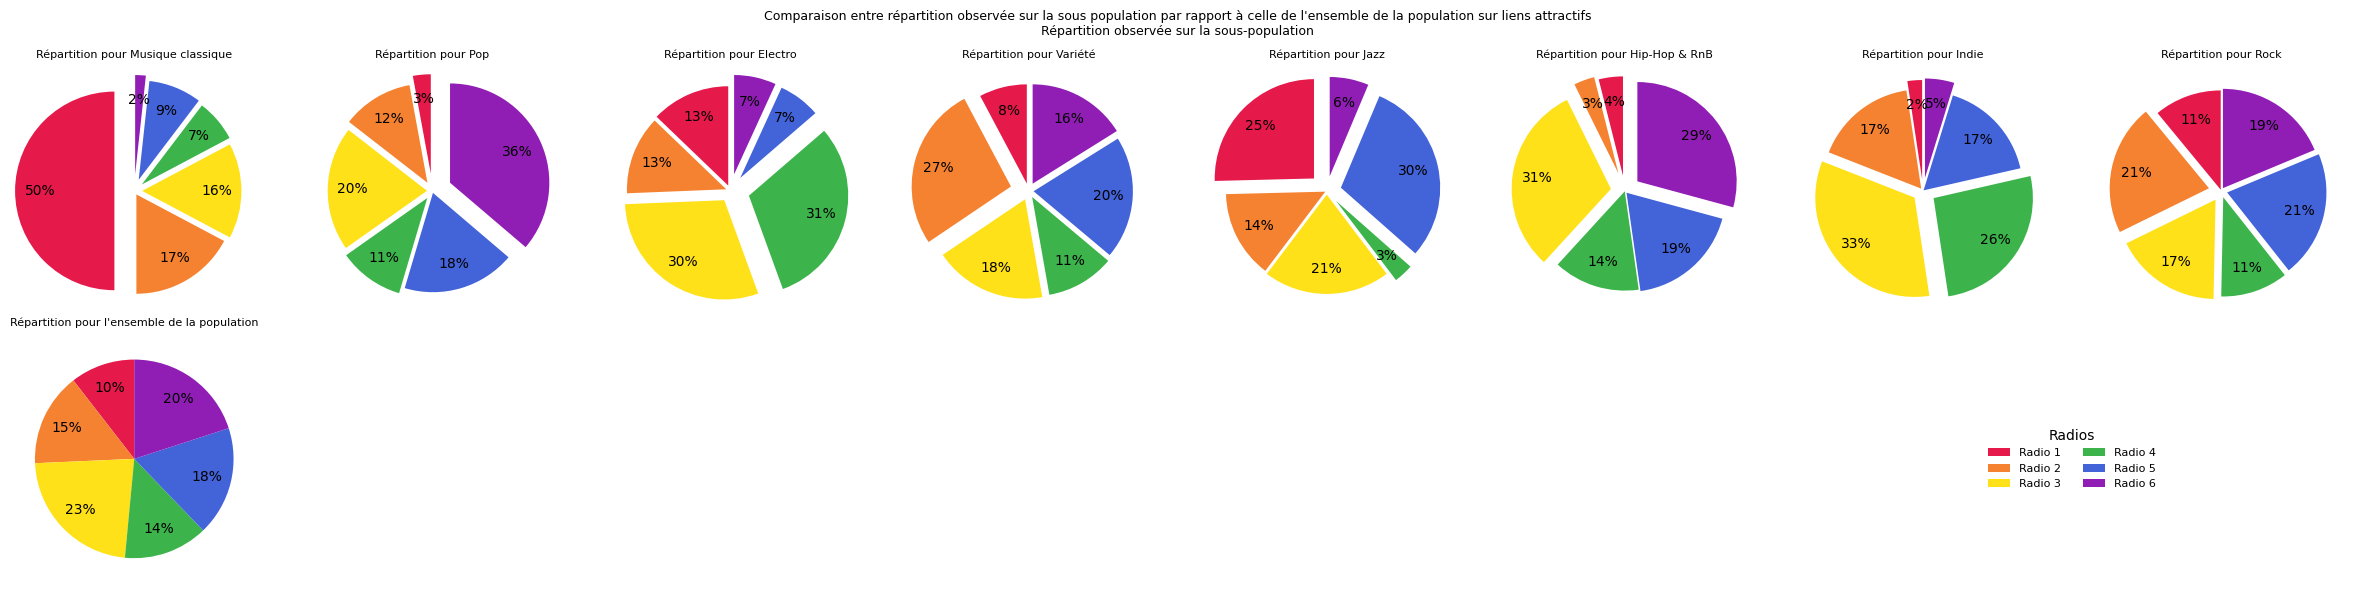

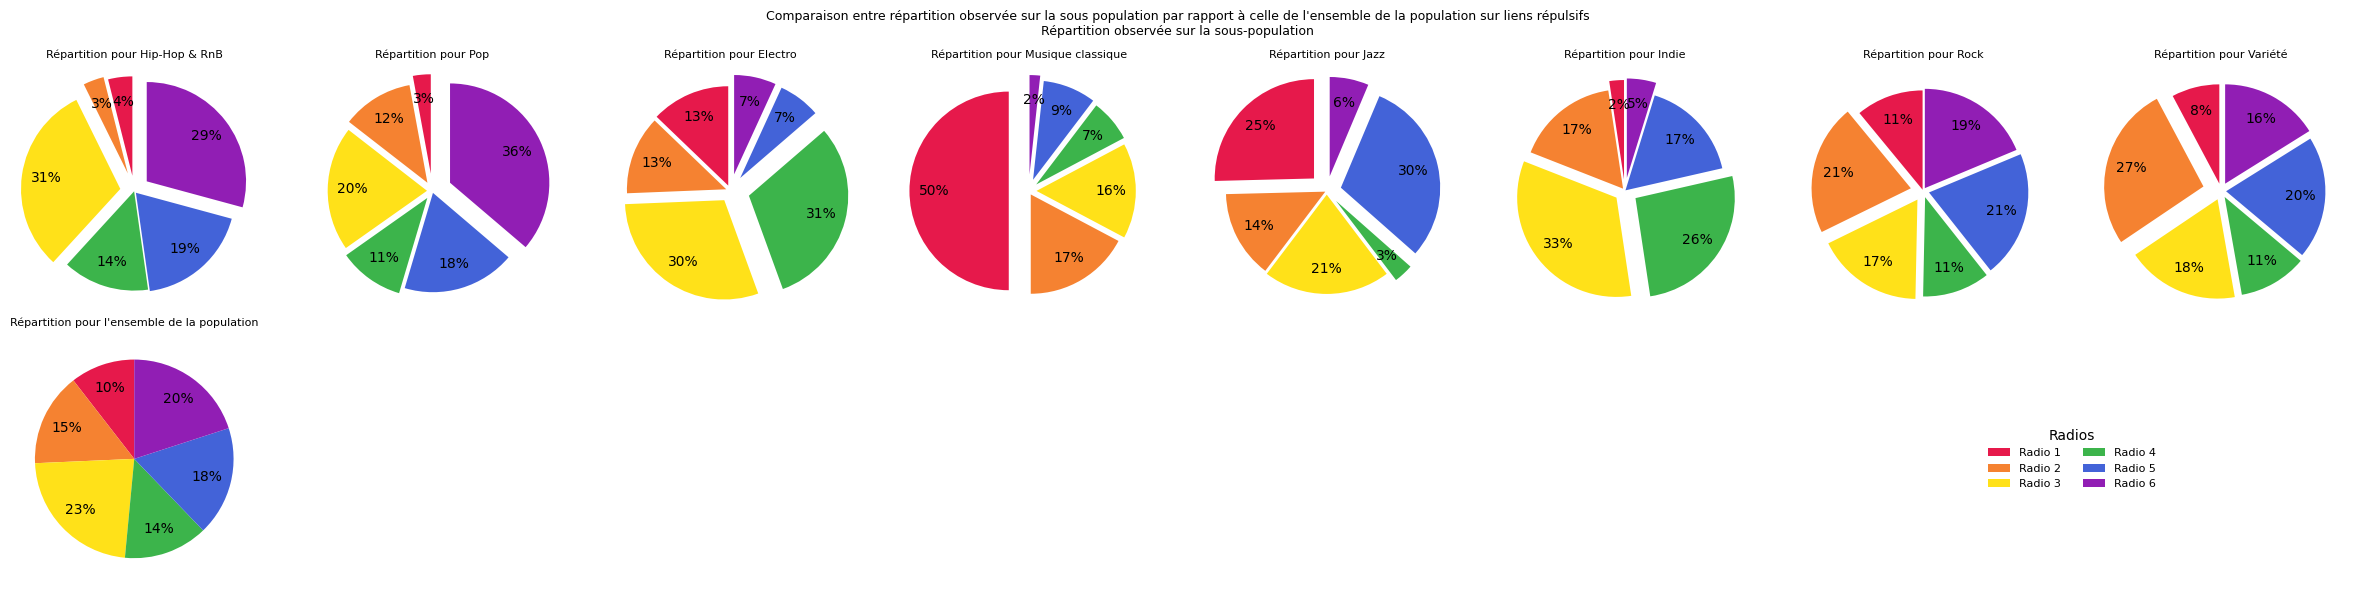

In [26]:
diagrammes(eff_obs_radios, eff_theo_radios, ana_contrib_radios, '+')
diagrammes(eff_obs_radios, eff_theo_radios, ana_contrib_radios, '-')

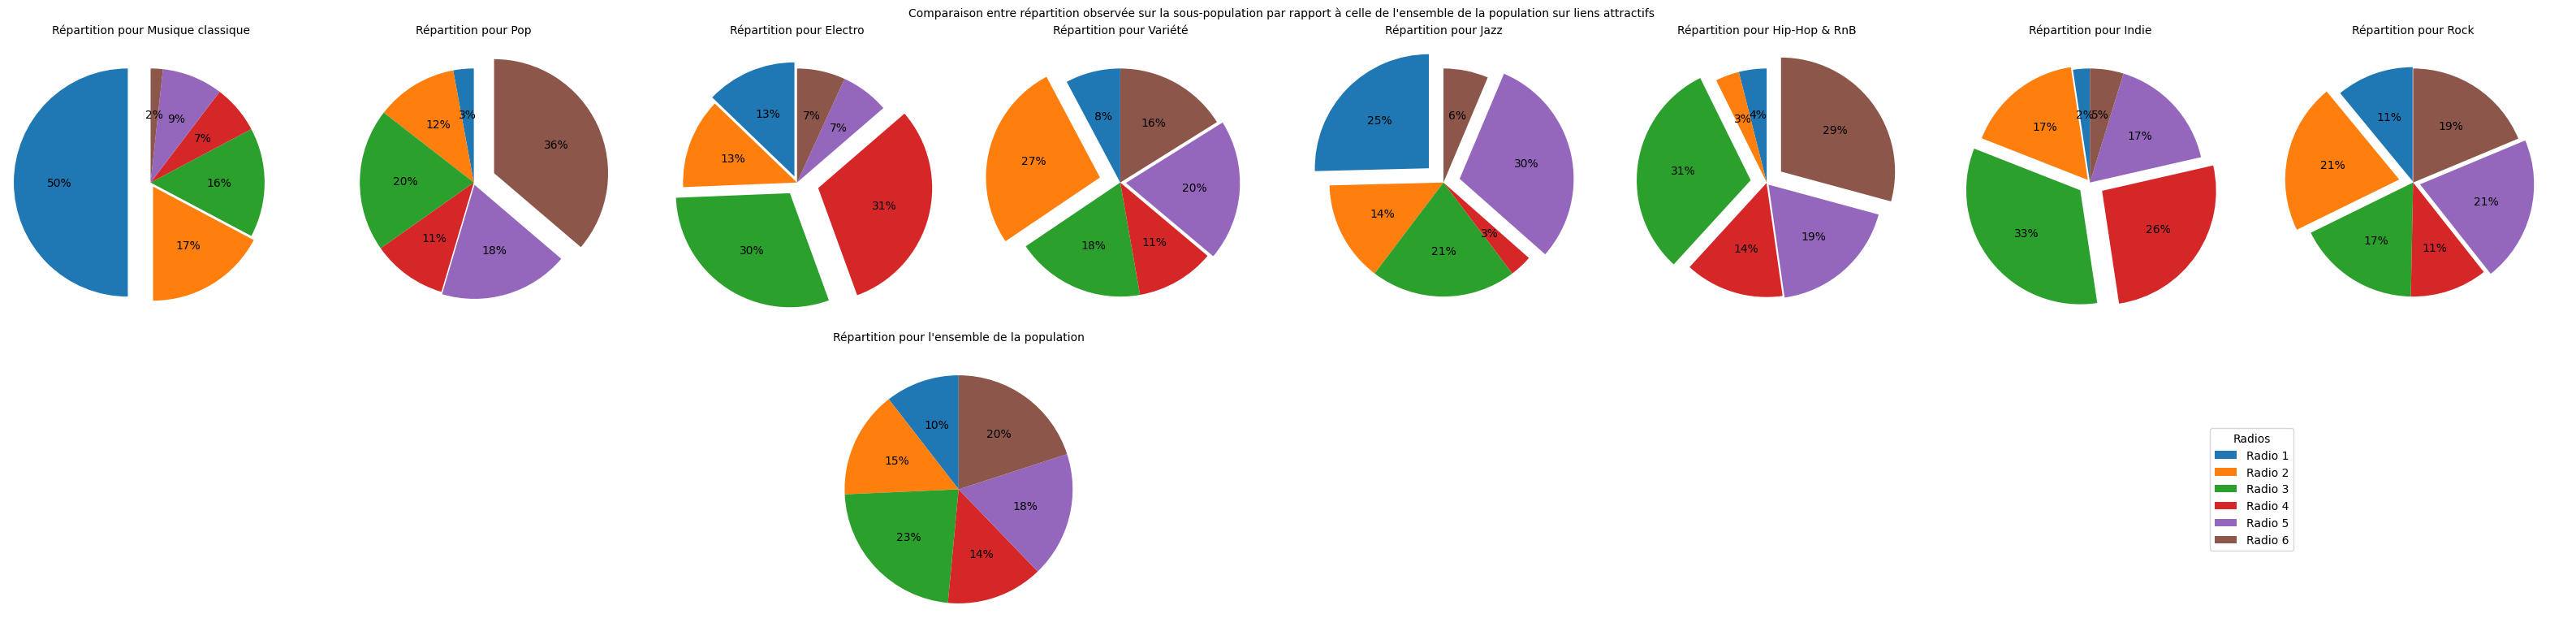

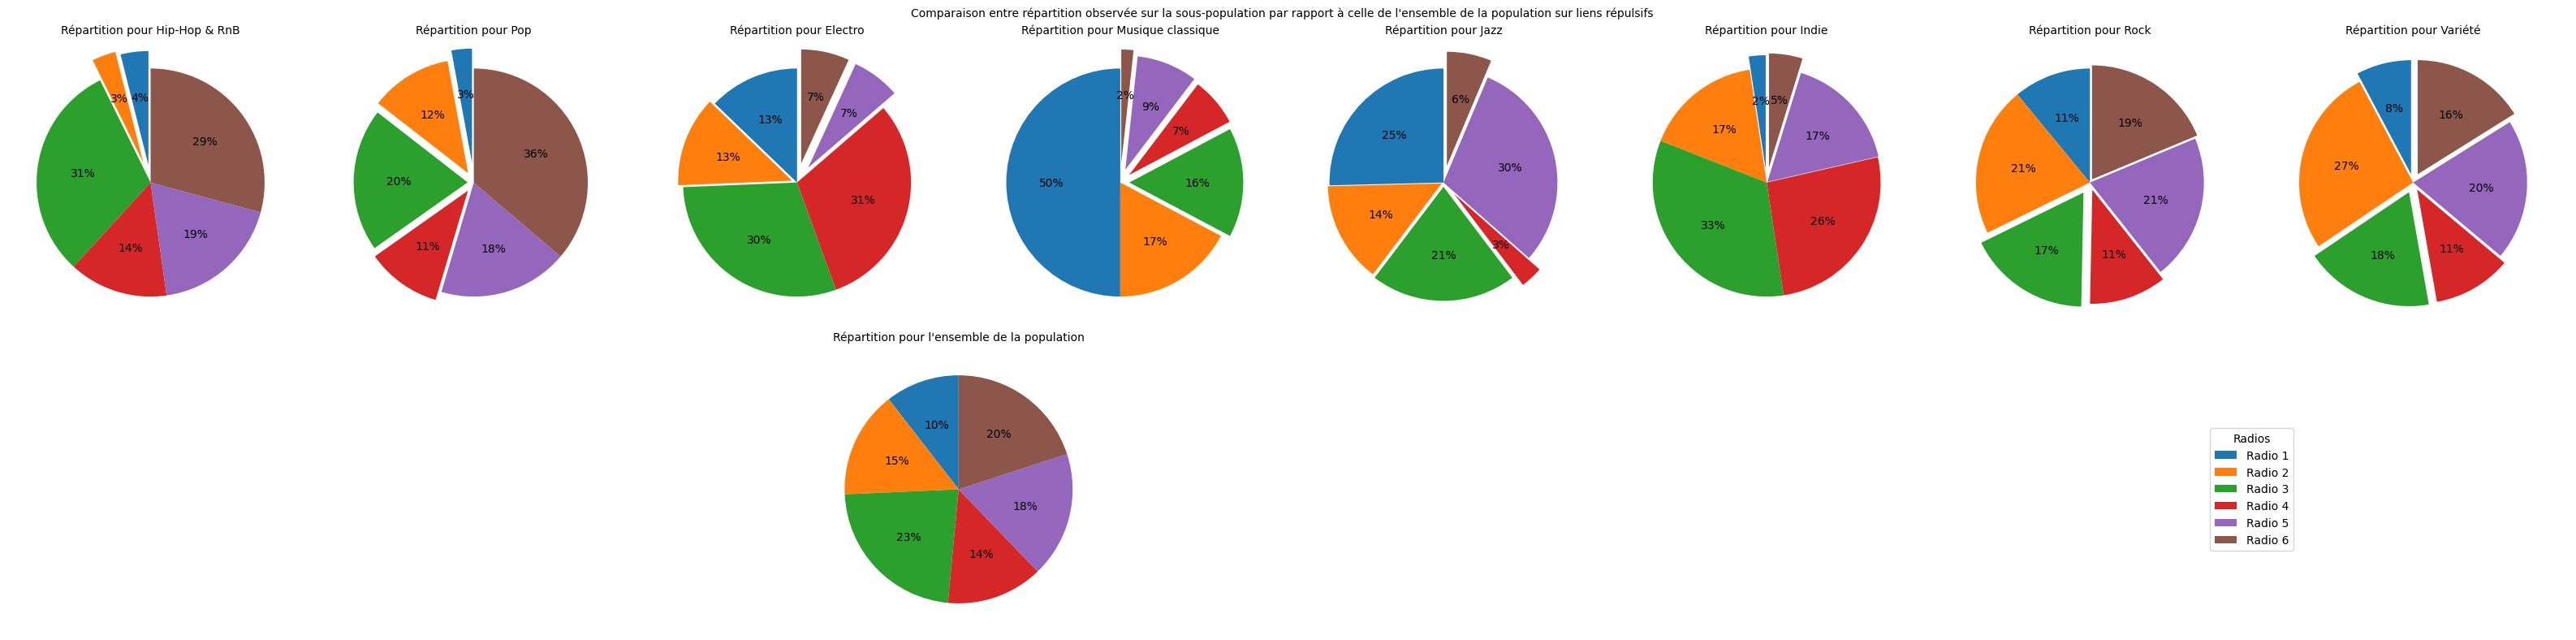

In [27]:
# 5) Diagrammes des résultats (camemberts comme dans le PDF)
def diagramme(eff_obs, eff_theo, ana_contrib, lien):
    # On garde seulement les contributions du type demandé : '+' ou '-'
    contrib_filtrees = []

    for rang, (style, radio, signe, valeur) in enumerate(ana_contrib):
        if signe == lien:
            contrib_filtrees.append((rang, style, radio, valeur))

    # Si aucune contribution ne correspond
    if len(contrib_filtrees) == 0:
        fig = plt.figure(figsize=(10, 6))

        if lien == '+':
            texte_lien = "attractifs"
        else:
            texte_lien = "répulsifs"

        fig.suptitle(
            "Comparaison entre répartition observée sur la sous-population "
            "par rapport à celle de l'ensemble de la population sur liens " + texte_lien,
            fontsize=10
        )

        plt.text(
            0.5,
            0.5,
            "Aucun lien de dépendance de type " + texte_lien + " à représenter",
            ha="center",
            va="center"
        )

        plt.axis("off")
        plt.show()
        return

    radios = eff_obs.columns.tolist()

    # Récupérer les styles concernés sans doublon
    styles = []

    for rang, style, radio, valeur in contrib_filtrees:
        if style not in styles:
            styles.append(style)

    nb_styles = len(styles)

    # Préparer les explode
    max_explode = 0.2
    nb_contrib_total = len(ana_contrib)

    explode_par_style = {}

    for style in styles:
        explode_par_style[style] = [0.0] * len(radios)

    for rang, style, radio, valeur in contrib_filtrees:
        if radio in radios:
            indice_radio = radios.index(radio)

            explode_value = max_explode * (nb_contrib_total - rang) / nb_contrib_total

            explode_par_style[style][indice_radio] = max(
                explode_par_style[style][indice_radio],
                explode_value
            )

    # Organisation de la figure
    nb_emplacements_legende = 1 if nb_styles < 4 else 2
    nb_colonnes = max(nb_styles, nb_emplacements_legende + 1)

    fig = plt.figure(figsize=(4 * nb_colonnes, 8))
    gs = GridSpec(2, nb_colonnes, figure=fig)

    # Première ligne : sous-populations
    for i, style in enumerate(styles):
        ax = fig.add_subplot(gs[0, i])

        valeurs = eff_obs.loc[style].reindex(radios).fillna(0)

        ax.pie(
            valeurs,
            labels=None,
            autopct="%1.0f%%",
            startangle=90,
            explode=explode_par_style[style]
        )

        ax.set_title("Répartition pour " + style, fontsize=10)

    # Deuxième ligne : population globale
    ax_global = fig.add_subplot(gs[1, 0:nb_colonnes - nb_emplacements_legende])

    total_population = eff_obs.sum(axis=0).reindex(radios).fillna(0)

    wedges, texts, autotexts = ax_global.pie(
        total_population,
        labels=None,
        autopct="%1.0f%%",
        startangle=90
    )

    ax_global.set_title("Répartition pour l'ensemble de la population", fontsize=10)

    # Légende
    ax_legende = fig.add_subplot(gs[1, nb_colonnes - nb_emplacements_legende:nb_colonnes])
    ax_legende.axis("off")

    ax_legende.legend(
        wedges,
        radios,
        title="Radios",
        loc="center"
    )

    if lien == '+':
        texte_lien = "attractifs"
    else:
        texte_lien = "répulsifs"

    fig.suptitle(
        "Comparaison entre répartition observée sur la sous-population "
        "par rapport à celle de l'ensemble de la population sur liens " + texte_lien,
        fontsize=10
    )

    plt.tight_layout()
    plt.show()

# Appel du tracé (étape 5)
diagramme(eff_obs_radios, eff_theo_radios, ana_contrib_radios, '+')
diagramme(eff_obs_radios, eff_theo_radios, ana_contrib_radios, '-')

